# 01. MetroPT-3 telemetry audit & failure verification

**Module A of CompressorGuard**: unsupervised condition monitoring of an industrial air compressor using real IIoT telemetry from the **MetroPT-3** dataset (Veloso et al., *Scientific Data*, 2022; Davari et al., DSAA 2021).

The data come from the Air Production Unit (APU) compressor of a Porto metro train, February–August 2020. The public CSV holds ~1.52 M rows at one reading about every 10 s. The UCI page says the unit logged at 1 Hz, so the published file appears to be downsampled roughly 10×.

### What this notebook establishes
1. **Schema & memory**: parse the CSV and downcast types.
2. **Sampling integrity**: interval distribution and outages (> 60 s gaps).
3. **Frozen-logger periods**: stretches where rows keep arriving but every analog signal is stuck. These must be masked before modelling.
4. **Sensor ranges** against physical expectations.
5. **Signal semantics**: which state of `COMP` actually means the compressor is producing air. *This turns out to be the opposite of the intuitive reading.*
6. **Operating cycles & (assumed) shifts.**
7. **Ground-truth verification** of the 4 reported air-leak failures, including the logged maintenance times.
8. **Seven-month timeline** with failures and data-quality issues marked.
9. **Clean parquet cache** for notebook 02.

In [2]:
import sys
import warnings
from pathlib import Path

# Make `src/` importable whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from compressor_guard.config import FIGURES_DIR, load_params

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
params = load_params()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
FAIL_COLOR, ALERT_COLOR, FROZEN_COLOR = "#d62728", "#ff7f0e", "#7f7f7f"

from compressor_guard.data import (ANALOG_COLS, DIGITAL_COLS, add_failure_labels, audit_frozen_periods,
                                   audit_sampling_gaps, audit_sensor_ranges, load_failures,
                                   load_raw_metropt, save_clean_parquet)
from compressor_guard.features import assign_operating_shifts, shifts_from_params

## 1. Ingestion & schema

Signal definitions follow the official UCI / paper descriptions:

| Signal | Unit | Meaning |
|---|---|---|
| `TP2` | bar | Pressure on the compressor. Near 0 when the compressor is not loading |
| `TP3` | bar | Pressure generated at the pneumatic panel |
| `H1` | bar | Pressure drop when the cyclonic separator filter discharges |
| `DV_pressure` | bar | Pressure drop when the towers discharge the air dryers. **Zero while the compressor is under load** |
| `Reservoirs` | bar | Downstream reservoir pressure (should track `TP3`) |
| `Oil_temperature` | °C | Compressor oil temperature |
| `Motor_current` | A | One phase of the motor: ~0 A off, ~4 A offloaded, ~7 A loaded, ~9 A starting |
| `COMP` | 0/1 | Air-intake valve signal. **Active (1) when there is no air intake, i.e. the compressor is off or offloaded** |
| `DV_eletric` | 0/1 | Compressor outlet valve. Active (1) when the compressor is **under load** |
| `Towers` | 0/1 | Which drying tower is active |
| `MPG` | 0/1 | Starts the compressor under load when APU pressure < 8.2 bar |
| `LPS` | 0/1 | Low-pressure switch: pressure < 7 bar |
| `Pressure_switch` | 0/1 | Discharge detected in the air-drying towers |
| `Oil_level` | 0/1 | Active when the oil is below the expected level |
| `Caudal_impulses` | 0/1 | Pulses from the air-flow meter |

In [3]:
csv_path = ROOT / params["metropt"]["raw_csv_path"]
df_raw = load_raw_metropt(csv_path, optimize_types=True)

span = df_raw["timestamp"].max() - df_raw["timestamp"].min()
print(f"Rows:     {len(df_raw):,}")
print(f"Period:   {df_raw['timestamp'].min()} -> {df_raw['timestamp'].max()} ({span.days} days)")
print(f"Memory:   {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB after downcasting")
print(f"Missing:  {int(df_raw.isna().sum().sum())} null values")
df_raw.head()

Rows:     1,516,948
Period:   2020-02-01 00:00:00 -> 2020-09-01 03:59:50 (213 days)
Memory:   63.7 MB after downcasting
Missing:  0 null values


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.599998,0.0400,1,0,1,1,0,1,1,1
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.674999,0.0400,1,0,1,1,0,1,1,1
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.599998,0.0425,1,0,1,1,0,1,1,1
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.424999,0.0400,1,0,1,1,0,1,1,1
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.474998,0.0400,1,0,1,1,0,1,1,1


## 2. Sampling interval & outages

The nominal interval is 10 s. Longer gaps come from the train being powered down or from logger outages. Later, the rolling features use **time-based** windows and ignore empty minutes, so gaps never get filled with invented values.

Most common sampling intervals (s):


,rows
timestamp,
10.0,1337521
9.0,128277
12.0,38321
13.0,7988
11.0,4471


Share of intervals within 9-11 s: 96.9%

331 gaps > 60 s, totalling 909.5 h (37.9 days)


,gap_start,gap_end,gap_hours
122,2020-04-25 01:10:51,2020-04-27 01:12:49,48.03
219,2020-06-27 10:53:07,2020-06-28 23:07:43,36.24
35,2020-02-28 23:57:08,2020-03-01 04:00:09,28.05
290,2020-08-04 07:42:28,2020-08-05 08:23:01,24.68
172,2020-05-24 00:39:23,2020-05-25 01:14:14,24.58
237,2020-07-07 15:24:51,2020-07-08 15:20:51,23.93
316,2020-08-22 19:11:44,2020-08-23 18:51:01,23.65
148,2020-05-10 00:31:17,2020-05-10 22:48:58,22.29


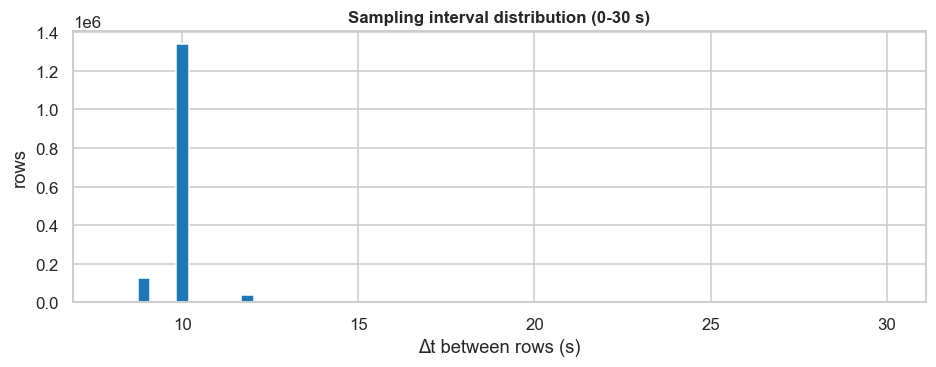

In [4]:
dt = df_raw["timestamp"].diff().dt.total_seconds()
print("Most common sampling intervals (s):")
display(dt.value_counts().head(5).rename("rows").to_frame())
print(f"Share of intervals within 9-11 s: {dt.between(9, 11).mean():.1%}")

gaps = audit_sampling_gaps(df_raw, threshold_seconds=60)
print(f"\n{len(gaps):,} gaps > 60 s, totalling {gaps['gap_hours'].sum():.1f} h "
      f"({gaps['gap_hours'].sum() / 24:.1f} days)")
display(gaps.sort_values("gap_hours", ascending=False).head(8)[["gap_start", "gap_end", "gap_hours"]].round(2))

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.hist(dt[dt.between(0, 30)], bins=60, color="#1f77b4")
ax.set(title="Sampling interval distribution (0-30 s)", xlabel="Δt between rows (s)", ylabel="rows")
plt.show()

## 3. Frozen-logger periods

Some stretches keep producing rows while **every analog signal stays exactly constant**, e.g. motor current fixed at 0.04 A and reservoir pressure fixed at 8.17 bar for a day. A running pneumatic system never holds seven analog sensors perfectly flat for a whole minute, so these are data-acquisition faults, not machine states.

A minute is counted as frozen when it has ≥ 3 rows and zero range on all seven analog signals. The feature pipeline applies the same rule (and so does the streaming pipeline), and frozen minutes are **never trained on or scored**. Otherwise a detector would "discover" logger outages.

In [5]:
frozen = audit_frozen_periods(df_raw, min_duration_minutes=10)
frozen["hours"] = frozen["minutes"] / 60
print(f"{len(frozen)} frozen periods >= 10 min, {frozen['minutes'].sum():,} minutes "
      f"({frozen['minutes'].sum() / 1440:.1f} days) in total")
display(frozen.sort_values("minutes", ascending=False).round(2))

failures = load_failures(ROOT / "config/failures.yaml")
for f in failures:
    hit = frozen[(frozen["end"] >= f["start"] - pd.Timedelta(hours=72)) & (frozen["start"] <= f["end"])]
    if len(hit):
        print(f"{f['id']}: frozen data inside the 72 h before/during the failure -> "
              + ", ".join(f"{r.start:%m-%d %H:%M}–{r.end:%m-%d %H:%M}" for r in hit.itertuples()))

10 frozen periods >= 10 min, 10,222 minutes (7.1 days) in total


,start,end,minutes,hours
7,2020-06-22 15:07:00,2020-06-25 05:08:00,3722,62.03
4,2020-05-26 09:20:00,2020-05-27 13:43:00,1704,28.40
3,2020-04-20 04:49:00,2020-04-21 01:16:00,1228,20.47
6,2020-06-12 02:02:00,2020-06-12 17:05:00,904,15.07
2,2020-04-17 09:21:00,2020-04-18 00:17:00,897,14.95
5,2020-05-27 13:54:00,2020-05-28 03:16:00,803,13.38
8,2020-07-21 13:45:00,2020-07-21 22:02:00,498,8.30
9,2020-07-22 06:44:00,2020-07-22 13:03:00,380,6.33
1,2020-04-13 18:30:00,2020-04-13 19:26:00,57,0.95
0,2020-03-11 18:30:00,2020-03-11 18:58:00,29,0.48


F1: frozen data inside the 72 h before/during the failure -> 04-17 09:21–04-18 00:17
F2: frozen data inside the 72 h before/during the failure -> 05-26 09:20–05-27 13:43, 05-27 13:54–05-28 03:16


**F1 is the one to watch:** the logger was frozen from 17 Apr 09:21 until just after the failure window opened (18 Apr 00:17). Nothing in this dataset *can* give an early warning for F1, and that limit applies to every model.

## 4. Physical sensor ranges

In [6]:
ranges = audit_sensor_ranges(df_raw)
display(ranges.style.format({c: "{:.2f}" for c in ["missing_pct", "min", "p01", "median", "mean", "p99", "max", "std"]}))

,signal,type,missing_count,missing_pct,min,p01,median,mean,p99,max,std
0,TP2,analog,0,0.00,-0.03,-0.02,-0.01,1.37,10.35,10.68,3.25
1,TP3,analog,0,0.00,0.73,7.88,8.96,8.98,10.14,10.30,0.64
2,H1,analog,0,0.00,-0.04,-0.02,8.78,7.57,10.11,10.29,3.33
3,DV_pressure,analog,0,0.00,-0.03,-0.03,-0.02,0.06,2.11,9.84,0.38
4,Reservoirs,analog,0,0.00,0.71,7.88,8.96,8.99,10.14,10.30,0.64
5,Oil_temperature,analog,0,0.00,15.40,48.83,62.70,62.64,76.18,89.05,6.52
6,Motor_current,analog,0,0.00,0.02,0.04,0.05,2.05,6.19,9.30,2.30
7,COMP,digital,0,0.00,0.00,0.00,1.00,0.84,1.00,1.00,0.37
8,DV_eletric,digital,0,0.00,0.00,0.00,0.00,0.16,1.00,1.00,0.37
9,Towers,digital,0,0.00,0.00,0.00,1.00,0.92,1.00,1.00,0.27


Pressures sit in the expected 0–10.5 bar band, and all digital columns are binary. Oil temperature has a long tail on both sides: cold starts in winter, and hot full-load episodes above 80 °C.

## 5. What does `COMP` mean? Verifying signal semantics

A natural first guess is that `COMP = 1` means "compressor running". The documentation says the opposite: `COMP` is the air-intake valve signal and is active **when there is no air intake**. The data settle it:

In [7]:
print("COMP vs DV_eletric (outlet valve, 1 = under load):")
display(pd.crosstab(df_raw["COMP"], df_raw["DV_eletric"], margins=True))

stats = df_raw.groupby("COMP").agg(rows=("COMP", "size"), motor_current_A=("Motor_current", "mean"),
                                   TP2_bar=("TP2", "mean"), DV_pressure_bar=("DV_pressure", "mean"))
display(stats.round(3))
loaded_share = (df_raw["COMP"] == 0).mean()
print(f"Overall share of time loaded (COMP == 0): {loaded_share:.1%}")

COMP vs DV_eletric (outlet valve, 1 = under load):


DV_eletric,0,1,All
COMP,,,
0,10226,237102,247328
1,1263084,6536,1269620
All,1273310,243638,1516948


,rows,motor_current_A,TP2_bar,DV_pressure_bar
COMP,,,,
0,247328,5.604,8.406,0.423
1,1269620,1.358,-0.003,-0.016


Overall share of time loaded (COMP == 0): 16.3%


When `COMP == 0`, motor current averages ~5.6 A (loaded), `TP2` carries ~8.4 bar (vs ~0 otherwise), and the outlet valve `DV_eletric` is 1 in 96 % of rows. When `COMP == 1`, current averages ~1.4 A (off, or ~4 A offloaded) and `DV_eletric` is 0 in 99.5 % of rows.

> **Consequence:** the compressor's loaded duty cycle is `mean(1 − COMP)`. It runs about 10–20 % of the time when healthy, and near 100 % during a leak. The earlier draft of this project used `mean(COMP)`, which measures *idle* time and inverts every duty-cycle feature. It is fixed in `features.py` (`loaded = 1 − COMP`).

## 6. Operating cycles & shifts

Shifts are **assumed** (06–14, 14–22, 22–06, set in `config/params.yaml`). MetroPT-3 does not record them. They are used later to check whether alerts cluster in a particular operating period.

,rows,loaded_duty,motor_current_A,oil_temp_C,reservoir_bar
shift,,,,,
Shift 1 (06-14),"550,852",15.8%,2.04,62.8,9.00
Shift 2 (14-22),"520,547",16.1%,2.06,63.6,8.99
Shift 3 (22-06),"445,549",17.1%,2.06,61.4,8.96


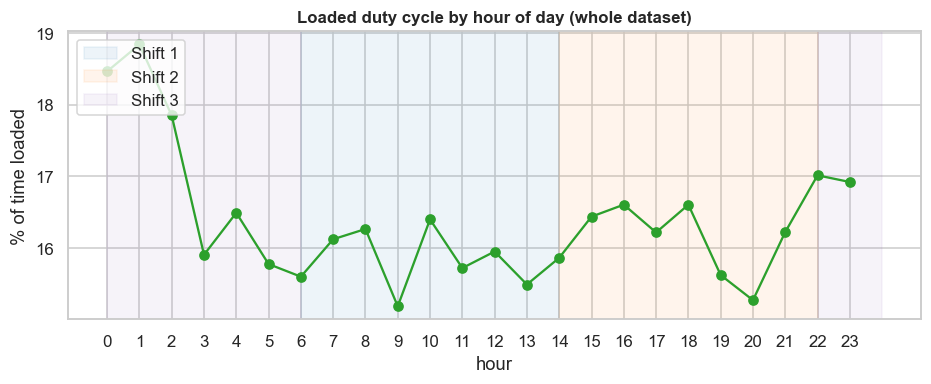

In [8]:
dfs = assign_operating_shifts(df_raw, shifts=shifts_from_params(params))
dfs["loaded"] = 1 - dfs["COMP"]

shift_summary = dfs.groupby("shift", observed=True).agg(
    rows=("loaded", "size"), loaded_duty=("loaded", "mean"),
    motor_current_A=("Motor_current", "mean"), oil_temp_C=("Oil_temperature", "mean"),
    reservoir_bar=("Reservoirs", "mean"))
display(shift_summary.style.format({"rows": "{:,}", "loaded_duty": "{:.1%}", "motor_current_A": "{:.2f}",
                                    "oil_temp_C": "{:.1f}", "reservoir_bar": "{:.2f}"}))

hourly = dfs.groupby("hour")["loaded"].mean() * 100
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(hourly.index, hourly.values, marker="o", color="#2ca02c")
for (a, b), c, lab in [((6, 14), "#1f77b4", "Shift 1"), ((14, 22), "#ff7f0e", "Shift 2"),
                       ((22, 24), "#9467bd", "Shift 3"), ((0, 6), "#9467bd", None)]:
    ax.axvspan(a, b, color=c, alpha=0.08, label=lab)
ax.set(title="Loaded duty cycle by hour of day (whole dataset)", xlabel="hour", ylabel="% of time loaded",
       xticks=range(24))
ax.legend(loc="upper left")
plt.show()

The compressor works hardest in the early morning (ramp-up) and during service hours, and is lightest overnight when the train is parked.

## 7. Ground-truth failure verification

The UCI page publishes the operator's failure report (no failure column exists in the CSV):

| Nr | Start | End | Failure | Maintenance (report) |
|---|---|---|---|---|
| F1 | 2020-04-18 00:00 | 2020-04-18 23:59 | Air leak | — |
| F2 | 2020-05-29 23:30 | 2020-05-30 06:00 | Air leak | 30 May 12:00 *(source says "30Apr", a typo)* |
| F3 | 2020-06-05 10:00 | 2020-06-07 14:30 | Air leak | 8 Jun 16:00 |
| F4 | 2020-07-15 14:30 | 2020-07-15 19:00 | Air leak | 16 Jul 00:00 |

These are encoded in `config/failures.yaml`. The maintenance time closes each incident: alerts between the end of a failure and its repair belong to that failure in the back-test.

**Expected physics of an air leak:** air escapes → reservoir pressure decays faster while idle → the compressor starts more often and runs longer (or never unloads) → oil temperature rises and the motor runs loaded almost continuously.

,hours,"loaded duty, 24h before","loaded duty, during","oil °C, 24h before","oil °C, during","reservoir bar, 24h before","reservoir bar, during"
failure,,,,,,,
F1,24.000000,16.5%,99.2%,50.45,74.13,8.47,8.81
F2,6.500000,13.9%,99.2%,66.25,75.87,9.02,8.40
F3,52.500000,11.3%,100.0%,63.83,75.52,9.02,8.02
F4,4.500000,39.3%,97.3%,72.79,83.91,9.11,8.21


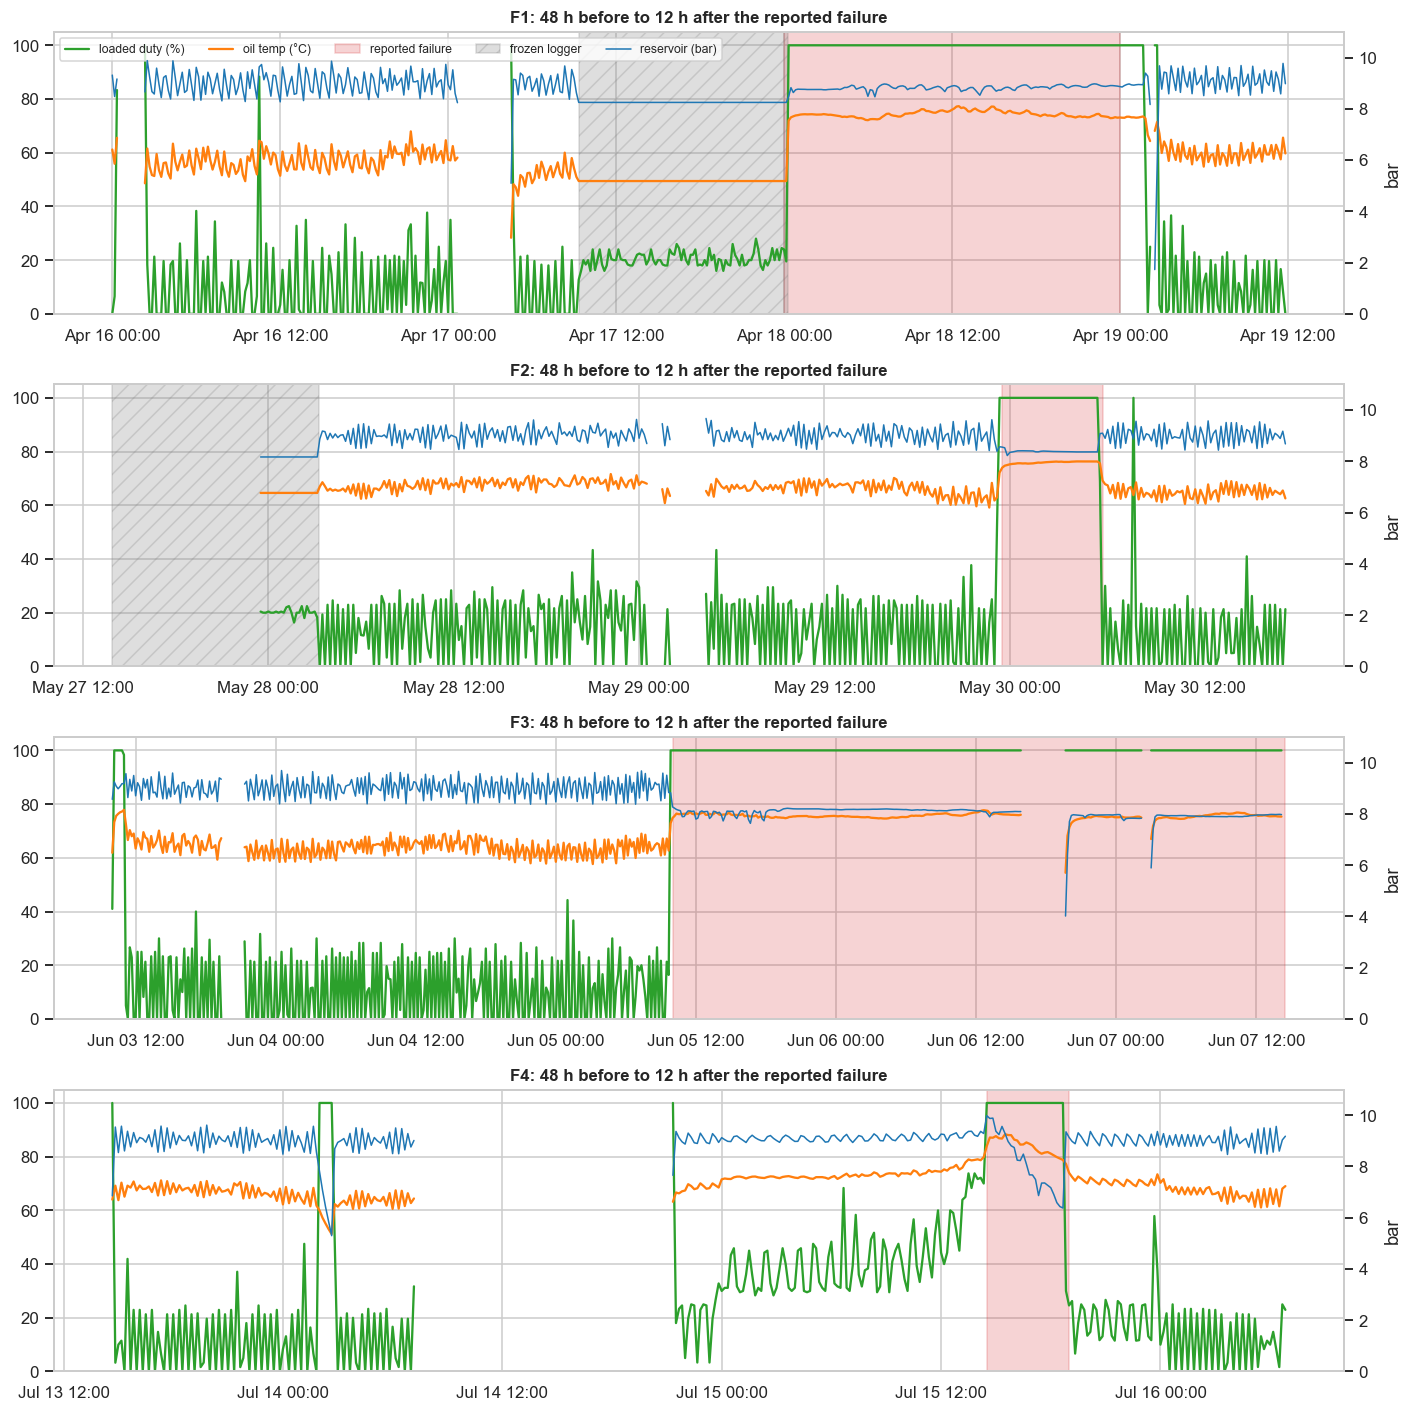

In [9]:
rows = []
for f in failures:
    pre = dfs[(dfs["timestamp"] >= f["start"] - pd.Timedelta(hours=24)) & (dfs["timestamp"] < f["start"])]
    dur = dfs[(dfs["timestamp"] >= f["start"]) & (dfs["timestamp"] <= f["end"])]
    rows.append({"failure": f["id"], "hours": round((f["end"] - f["start"]).total_seconds() / 3600, 1),
                 "loaded duty, 24h before": pre["loaded"].mean(), "loaded duty, during": dur["loaded"].mean(),
                 "oil °C, 24h before": pre["Oil_temperature"].mean(), "oil °C, during": dur["Oil_temperature"].mean(),
                 "reservoir bar, 24h before": pre["Reservoirs"].mean(), "reservoir bar, during": dur["Reservoirs"].mean()})
fail_tbl = pd.DataFrame(rows).set_index("failure")
display(fail_tbl.style.format({c: "{:.1%}" if "duty" in c else "{:.2f}" for c in fail_tbl.columns if c != "hours"}))

fig, axes = plt.subplots(4, 1, figsize=(13, 13))
for ax, f in zip(axes, failures):
    w = dfs[(dfs["timestamp"] >= f["start"] - pd.Timedelta(hours=48)) &
            (dfs["timestamp"] <= f["end"] + pd.Timedelta(hours=12))].set_index("timestamp")
    r = w[["loaded", "Oil_temperature", "Reservoirs"]].resample("10min").mean()
    ax.plot(r.index, r["loaded"] * 100, color="#2ca02c", label="loaded duty (%)")
    ax.plot(r.index, r["Oil_temperature"], color="#ff7f0e", label="oil temp (°C)")
    ax2 = ax.twinx()
    ax2.plot(r.index, r["Reservoirs"], color="#1f77b4", lw=1, label="reservoir (bar)")
    ax2.set_ylim(0, 11); ax2.grid(False); ax2.set_ylabel("bar")
    ax.axvspan(f["start"], f["end"], color=FAIL_COLOR, alpha=0.2, label="reported failure")
    for fr in frozen.itertuples():
        if fr.end >= r.index.min() and fr.start <= r.index.max():
            ax.axvspan(fr.start, fr.end, color=FROZEN_COLOR, alpha=0.25, hatch="//", label="frozen logger")
    ax.set_title(f"{f['id']}: 48 h before to 12 h after the reported failure")
    ax.set_ylim(0, 105)
    if f["id"] == "F1":
        h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper left", ncol=5, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
plt.tight_layout()
plt.show()

All four failures show the expected leak physics *during* the reported window: loaded duty jumps to ~100 % and oil temperature to 74–86 °C. In the run-up, **F4** shows a clear precursor (see notebook 02: idle pressure decay and compressor starts climb for ~15 h), **F2** and **F3** only faint ones, and **F1** is hidden behind the frozen logger.

## 8. Seven-month timeline

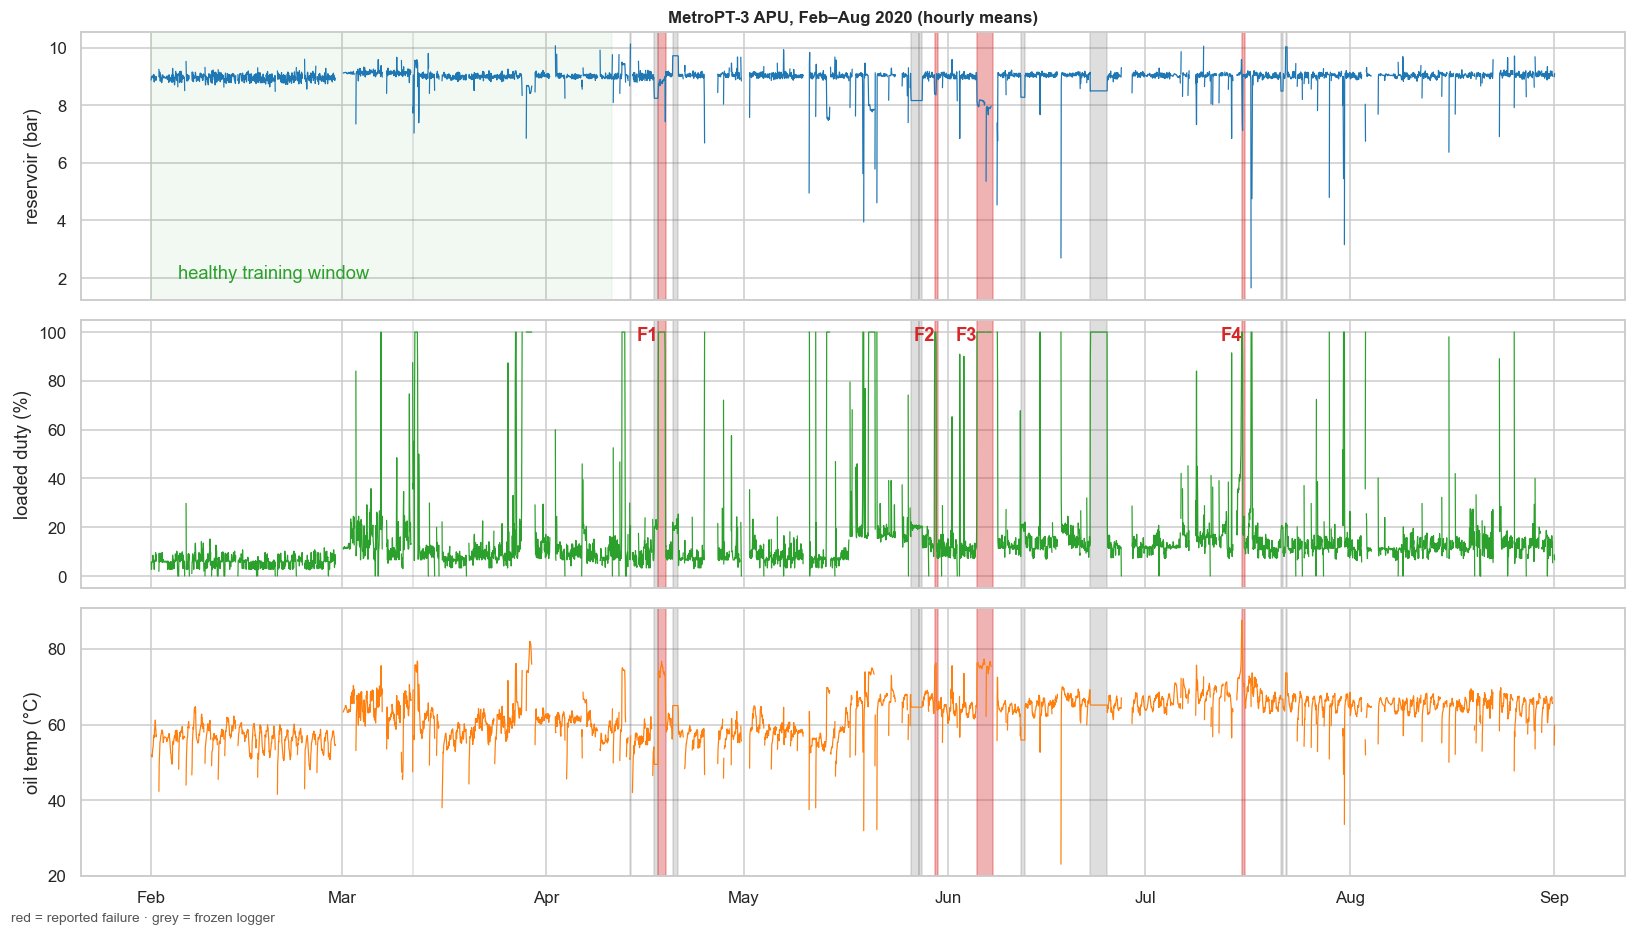

In [10]:
macro = dfs.set_index("timestamp")[["Reservoirs", "Oil_temperature", "Motor_current", "loaded"]].resample("1h").mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 8.5), sharex=True)
axes[0].plot(macro.index, macro["Reservoirs"], lw=0.8, color="#1f77b4")
axes[0].set(ylabel="reservoir (bar)", title="MetroPT-3 APU, Feb–Aug 2020 (hourly means)")
axes[1].plot(macro.index, macro["loaded"] * 100, lw=0.8, color="#2ca02c")
axes[1].set(ylabel="loaded duty (%)")
axes[2].plot(macro.index, macro["Oil_temperature"], lw=0.8, color="#ff7f0e")
axes[2].set(ylabel="oil temp (°C)")
for ax in axes:
    for f in failures:
        ax.axvspan(f["start"], f["end"] + pd.Timedelta(hours=6), color=FAIL_COLOR, alpha=0.35)
    for fr in frozen.itertuples():
        ax.axvspan(fr.start, fr.end, color=FROZEN_COLOR, alpha=0.25)
ymax = axes[1].get_ylim()[1]
for f in failures:
    axes[1].annotate(f["id"], (f["start"], ymax * 0.92), color=FAIL_COLOR, fontweight="bold", ha="right")
axes[0].axvspan(pd.Timestamp(params["metropt"]["train_split"]["start"]),
                pd.Timestamp(params["metropt"]["train_split"]["end"]), color="#2ca02c", alpha=0.06)
axes[0].annotate("healthy training window", (pd.Timestamp("2020-02-05"), 2.0), color="#2ca02c")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.text(0.01, 0.005, "red = reported failure · grey = frozen logger", fontsize=9, color="#555")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "metropt_timeline.png")
plt.show()

The hourly duty cycle also shows several **full-load episodes that are not in the failure report** (mid-March, late March, 12 April, mid-May). Notebook 02 examines them. Two of them fall inside the training window and are excluded from model fitting.

## 9. Findings & export

1. **Data volume & gaps:** ~1.52 M rows (1 Feb – 1 Sep 2020), 0 nulls. ~97 % of intervals are 9–11 s. There are 331 gaps > 60 s totalling ~38 days, the longest 48 h, from the train being powered down.
2. **Frozen logger:** 10,222 minutes (~7 days) in 10 periods where all analog sensors are stuck. They are masked from training and scoring. One period covers the 15 h right before F1, and two cover 26–28 May, shortly before F2.
3. **`COMP` is inverted:** loaded = `COMP == 0`, confirmed by motor current, `TP2`, `DV_pressure` and the outlet valve. Healthy loaded duty is ~10–20 %.
4. **Failure physics confirmed** for all four reported leaks. Maintenance times are added to `failures.yaml`.
5. **Unreported leak-like episodes** exist, so "no report" does not mean "healthy". Back-test false-alarm counts are an upper bound.

The labelled, type-optimised table is cached for notebook 02.

In [11]:
df_clean = add_failure_labels(df_raw, failures=failures)
out = save_clean_parquet(df_clean, ROOT / params["metropt"]["clean_parquet_path"])
print(f"Saved {out.relative_to(ROOT)} ({out.stat().st_size / 1024**2:.1f} MB); "
      f"{int(df_clean['is_failure'].sum()):,} rows inside failure windows")

Saved data/processed/metropt_clean.parquet (22.2 MB); 29,954 rows inside failure windows
